# 2. projekt


Oldja meg a következő kezdeti érték feladatot az RK4 módszerrel $10,20,50$ lépést használva. Ábrázolja a kapott közelítéseket az `ode45` által számolt eredménnyel közös ábrákon.
$$
\begin{gather*}
y'=\sin(2y)+\frac{\cos(t)}{t^2+2} \\
y(1)=2\\
y(7)=?
\end{gather*}
$$


## RK4

In [5]:
import numpy as np

def RK4(f, tspan, y0, L):
  t = np.linspace(tspan[0], tspan[1], L+1)
  h = t[1]-t[0]
  y = np.zeros(np.shape(t))
  y[0] = y0
  for it in range(1,L+1):
    k1 = f(t[it-1], y[it-1])
    k2 = f(t[it-1]+0.5*h, y[it-1]+0.5*h*k1)
    k3 = f(t[it-1]+0.5*h, y[it-1]+0.5*h*k2)
    k4 = f(t[it-1]+h, y[it-1]+h*k3)
    y[it] = y[it-1] + h*(k1 + 2*k2 + 2*k3 + k4)/6
  return (t,y)



In [6]:
f = lambda t,y: np.sin(2*y) + np.cos(t) / (t**2 + 2)
t0 = 1
tv = 7 
y0 = 0
nstep = 10
tspan = [t0, tv]
t10, y10 = RK4(f, tspan, y0, nstep)

In [7]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
import scipy as scp
rk45 = scp.integrate.solve_ivp(f, tspan, [y0], method = "RK45") # y0 must 1-dimensional
t45 = rk45.t     # rk45.t: (n,)
y45 = rk45.y[0]  # rk45.y: (1,n)

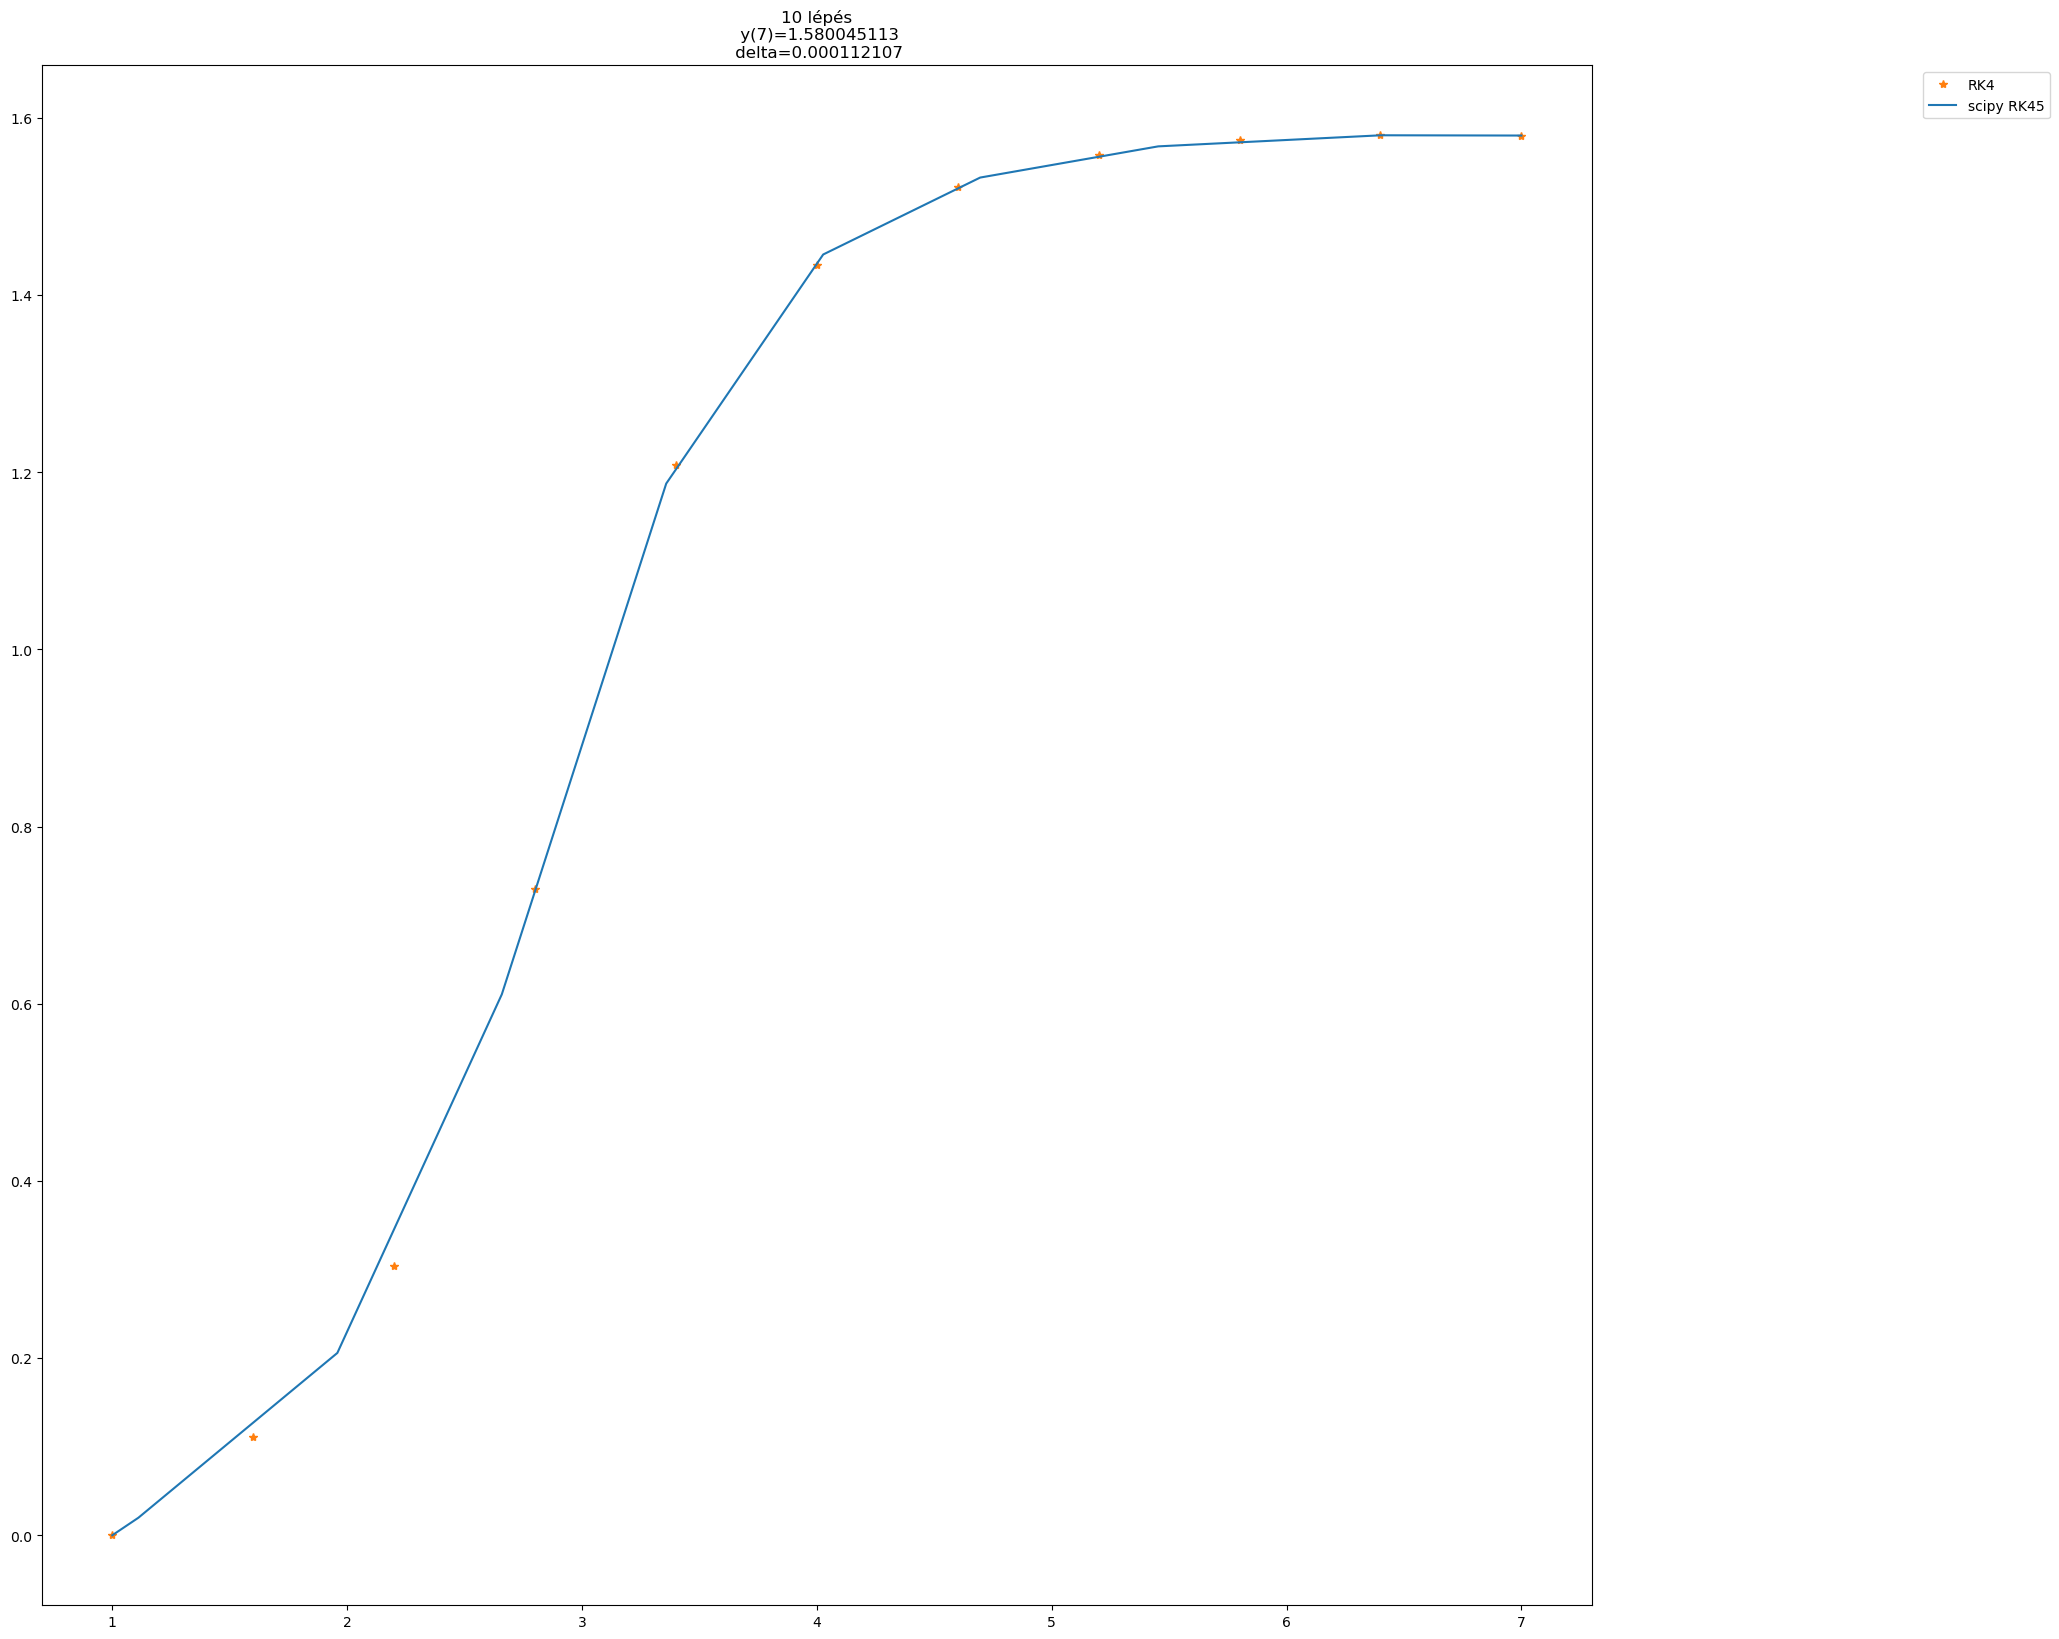

In [8]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=20,20


ax = plt.subplot()

ax.plot(t10, y10, "*", color = "tab:orange")
ax.plot(t45, y45, color = "tab:blue")

plt.legend(
  ["RK4", "scipy RK45"],
  bbox_to_anchor=(1.3, 1.0)
)
plt.title(f"{nstep} lépés\n y({tv})={y10[-1]:.9f}\n delta={np.abs(y10[-1]-y45[-1]):.9f}")

plt.show()
